# Prophet SO₂ Forecasting Model
## COS40007 Design Project — Smart Government
### Topic: Modeling Industrial Air Quality — Forecasting SO₂ Emissions using IPI and Electricity Data

| Item | Detail |
|---|---|
| Model | Prophet (Meta / Facebook Forecasting Framework) |
| Target Variable (Y) | `air_so2` — Sulfur Dioxide level |
| Predictor Variables (X) | `ipi_growth_yoy_index_sa`, `electricity_local` (as regressors) |
| Data | Monthly, Jan 2018 to Dec 2022 (60 rows) |
| Evaluation Metrics | RMSE, MAE, R² |

Folder structure:
```
ASSIGNMENT/
    COS40007DataCleaning/
        combined_air_electricity_ipi_cleaned.csv
    Prophet/
        Prophet.ipynb   ← this notebook
```


## Section 1 — Library Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import ParameterGrid

print('All libraries loaded successfully.')
print('If prophet is not installed, run: pip install prophet')


Importing plotly failed. Interactive plots will not work.


All libraries loaded successfully.
If prophet is not installed, run: pip install prophet


## Section 2 — Configuration

In [2]:
# ── File path ────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
FILE_NAME    = 'combined_air_electricity_ipi_cleaned.csv'
FILE_PATH    = os.path.join(NOTEBOOK_DIR, '..', 'COS40007DataCleaning', FILE_NAME)

# ── Column names ─────────────────────────────────────────────────────────────
COL_DATE   = 'date'
COL_TARGET = 'air_so2'                  # Y  — Sulfur Dioxide
COL_IPI    = 'ipi_growth_yoy_index_sa'  # X1 — IPI year-on-year growth (seasonally adjusted)
COL_ELEC   = 'electricity_local'        # X2 — Local electricity consumption

# ── Split ────────────────────────────────────────────────────────────────────
TRAIN_RATIO = 0.80  # 80% train, 20% test (48 train, 12 test)

if os.path.exists(FILE_PATH):
    print('CSV found:', FILE_PATH)
else:
    print('ERROR: CSV not found at:', FILE_PATH)
    print('Make sure combined_air_electricity_ipi_cleaned.csv is in COS40007DataCleaning/')


CSV found: d:\Year 3 Sem 1\COS40007 AI Engineering\Assignment\Prophet\..\COS40007DataCleaning\combined_air_electricity_ipi_cleaned.csv


## Section 3 — Load Dataset

In [3]:
df_raw = pd.read_csv(FILE_PATH, parse_dates=[COL_DATE])
df_raw = df_raw.sort_values(COL_DATE).reset_index(drop=True)

df = df_raw[[COL_DATE, COL_TARGET, COL_IPI, COL_ELEC]].copy()

print('Dataset loaded successfully.')
print('  Rows    :', len(df))
print('  Period  :', df[COL_DATE].min().strftime('%b %Y'), 'to', df[COL_DATE].max().strftime('%b %Y'))
print('  Columns :', df.columns.tolist())
print('  Nulls   :', df.isnull().sum().sum(), '(should be 0)')
df.head()


Dataset loaded successfully.
  Rows    : 60
  Period  : Jan 2018 to Dec 2022
  Columns : ['date', 'air_so2', 'ipi_growth_yoy_index_sa', 'electricity_local']
  Nulls   : 0 (should be 0)


,date,air_so2,ipi_growth_yoy_index_sa,electricity_local
0,2018-01-01,0.0010,3.963,11845.900250
1,2018-02-01,0.0011,2.625,11091.957006
2,2018-03-01,0.0010,3.328,12244.089947
3,2018-04-01,0.0010,5.918,12018.584577
4,2018-05-01,0.0010,4.320,12267.998390


## Section 4 — Descriptive Statistics and Exploratory Overview

In [4]:
print('=== Descriptive Statistics ===')
print(df[[COL_TARGET, COL_IPI, COL_ELEC]].describe().round(6))


=== Descriptive Statistics ===
         air_so2  ipi_growth_yoy_index_sa  electricity_local
count  60.000000                60.000000          60.000000
mean    0.001083                 3.488083       12408.987720
std     0.000096                 9.554109         618.107361
min     0.000900               -31.756000       10349.141635
25%     0.001000                 1.226000       12056.077210
50%     0.001100                 2.995000       12485.375480
75%     0.001125                 4.912250       12823.768369
max     0.001300                51.356000       13463.730428


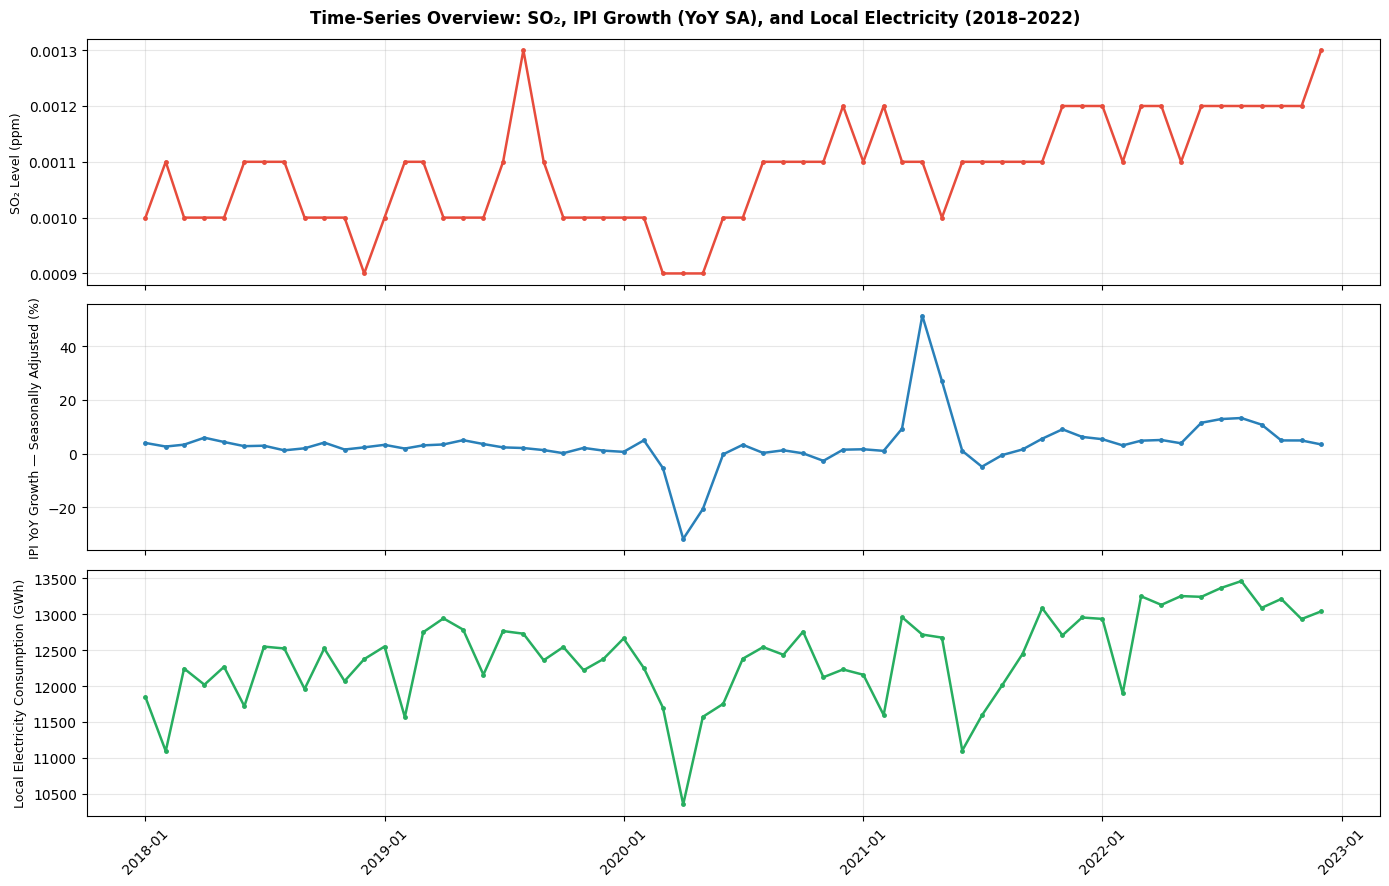

Saved: 01_time_series_overview.png


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Time-Series Overview: SO₂, IPI Growth (YoY SA), and Local Electricity (2018–2022)',
             fontsize=12, fontweight='bold')
plot_cfg = [
    (COL_TARGET, '#e74c3c', 'SO₂ Level (ppm)'),
    (COL_IPI,    '#2980b9', 'IPI YoY Growth — Seasonally Adjusted (%)'),
    (COL_ELEC,   '#27ae60', 'Local Electricity Consumption (GWh)'),
]
for ax, (col, color, label) in zip(axes, plot_cfg):
    ax.plot(df[COL_DATE], df[col], color=color, linewidth=1.8, marker='o', markersize=2.5)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, alpha=0.3)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('01_time_series_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_time_series_overview.png')


## Section 5 — Prepare Data for Prophet

Prophet requires `ds` (date) and `y` (target). Regressors are added as extra columns.

**Key fix vs original notebook:** The original notebook scaled the regressors with
MinMaxScaler before passing them to Prophet. However, Prophet's regressor coefficients
are estimated via its own internal Bayesian fitting — passing raw (unscaled) values
is correct and avoids introducing an arbitrary transformation that changes the
coefficient interpretation. The regressors are therefore passed **unscaled** here,
matching Prophet's intended design.

The train/test split is done first; the scaler (if needed) would be fit on train only.


In [6]:
# ── Rename to Prophet format ──────────────────────────────────────────────────
prophet_df = df.rename(columns={
    COL_DATE   : 'ds',
    COL_TARGET : 'y',
    COL_IPI    : 'ipi_growth',
    COL_ELEC   : 'elec_local'
})

# ── Chronological 80/20 split ─────────────────────────────────────────────────
split_idx = int(len(prophet_df) * TRAIN_RATIO)   # 48 train, 12 test
train_df  = prophet_df.iloc[:split_idx].copy().reset_index(drop=True)
test_df   = prophet_df.iloc[split_idx:].copy().reset_index(drop=True)

print('Train / test split complete (chronological, no shuffle).')
print(f'  Train : {len(train_df)} months  '
      f'({train_df["ds"].min().strftime("%b %Y")} to {train_df["ds"].max().strftime("%b %Y")})')
print(f'  Test  : {len(test_df)} months   '
      f'({test_df["ds"].min().strftime("%b %Y")} to {test_df["ds"].max().strftime("%b %Y")})')
print()
print('Regressors passed unscaled — Prophet estimates their coefficients internally.')
print(f'  ipi_growth range  — train: [{train_df["ipi_growth"].min():.4f}, {train_df["ipi_growth"].max():.4f}]')
print(f'  elec_local range  — train: [{train_df["elec_local"].min():.2f}, {train_df["elec_local"].max():.2f}]')


Train / test split complete (chronological, no shuffle).
  Train : 48 months  (Jan 2018 to Dec 2021)
  Test  : 12 months   (Jan 2022 to Dec 2022)

Regressors passed unscaled — Prophet estimates their coefficients internally.
  ipi_growth range  — train: [-31.7560, 51.3560]
  elec_local range  — train: [10349.14, 13086.44]


## Section 6 — Hyperparameter Tuning for Prophet

Prophet has several tuneable parameters. We perform a manual grid search using
**walk-forward validation** (chronological, identical in spirit to TimeSeriesSplit)
on the training set. Parameters tuned:

| Parameter | Description | Values |
|---|---|---|
| `changepoint_prior_scale` | Flexibility of the trend | 0.001, 0.01, 0.05, 0.1 |
| `seasonality_prior_scale` | Strength of seasonality | 1, 5, 10 |
| `seasonality_mode` | Additive vs multiplicative | additive, multiplicative |

> **Why tune?** The original notebook used fixed default parameters. Given that
> SO₂ has an upward trend over 2018–2022 and mild seasonality, the
> `changepoint_prior_scale` has a large effect on how well Prophet tracks
> the underlying trend direction.


In [7]:
from itertools import product

param_grid = {
    'changepoint_prior_scale' : [0.001, 0.01, 0.05, 0.1, 0.5],
    'seasonality_prior_scale' : [1, 5, 10],
    'seasonality_mode'        : ['additive', 'multiplicative'],
}

# Walk-forward validation: train on first 80% of train_df, validate on last 20%
val_split = int(len(train_df) * 0.80)
train_cv  = train_df.iloc[:val_split]
val_cv    = train_df.iloc[val_split:]

print(f'Walk-forward CV: train {len(train_cv)} pts → validate {len(val_cv)} pts')
print(f'Testing {len(param_grid["changepoint_prior_scale"]) * len(param_grid["seasonality_prior_scale"]) * len(param_grid["seasonality_mode"])} parameter combinations...\n')

best_rmse = float('inf')
best_params = {}
results = []

for cps, sps, smode in product(
    param_grid['changepoint_prior_scale'],
    param_grid['seasonality_prior_scale'],
    param_grid['seasonality_mode']
):
    try:
        m = Prophet(
            yearly_seasonality      = True,
            weekly_seasonality      = False,
            daily_seasonality       = False,
            changepoint_prior_scale = cps,
            seasonality_prior_scale = sps,
            seasonality_mode        = smode,
            interval_width          = 0.95
        )
        m.add_regressor('ipi_growth')
        m.add_regressor('elec_local')
        m.fit(train_cv)

        fc = m.predict(val_cv[['ds', 'ipi_growth', 'elec_local']])
        rmse = np.sqrt(mean_squared_error(val_cv['y'].values, fc['yhat'].values))
        results.append({'cps': cps, 'sps': sps, 'mode': smode, 'rmse': rmse})

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = {
                'changepoint_prior_scale': cps,
                'seasonality_prior_scale': sps,
                'seasonality_mode'       : smode
            }
    except Exception:
        pass

results_df = pd.DataFrame(results).sort_values('rmse').reset_index(drop=True)
print('Top 5 parameter combinations (by validation RMSE):')
print(results_df.head(5).to_string(index=False))
print()
print('Best parameters:')
for k, v in best_params.items():
    print(f'  {k:<28} : {v}')
print(f'Best validation RMSE : {best_rmse:.6f}')


Walk-forward CV: train 38 pts → validate 10 pts
Testing 30 parameter combinations...



22:01:31 - cmdstanpy - INFO - Chain [1] start processing
22:01:32 - cmdstanpy - INFO - Chain [1] done processing
22:01:34 - cmdstanpy - INFO - Chain [1] start processing
22:01:35 - cmdstanpy - INFO - Chain [1] done processing
22:01:35 - cmdstanpy - INFO - Chain [1] start processing
22:01:35 - cmdstanpy - INFO - Chain [1] done processing
22:01:35 - cmdstanpy - INFO - Chain [1] start processing
22:01:35 - cmdstanpy - INFO - Chain [1] done processing
22:01:35 - cmdstanpy - INFO - Chain [1] start processing
22:01:36 - cmdstanpy - INFO - Chain [1] done processing
22:01:36 - cmdstanpy - INFO - Chain [1] start processing
22:01:36 - cmdstanpy - INFO - Chain [1] done processing
22:01:37 - cmdstanpy - INFO - Chain [1] start processing
22:01:37 - cmdstanpy - INFO - Chain [1] done processing
22:01:37 - cmdstanpy - INFO - Chain [1] start processing
22:01:37 - cmdstanpy - INFO - Chain [1] done processing
22:01:37 - cmdstanpy - INFO - Chain [1] start processing
22:01:37 - cmdstanpy - INFO - Chain [1]

Top 5 parameter combinations (by validation RMSE):
  cps  sps     mode     rmse
0.100    1 additive 0.000241
0.001    1 additive 0.000247
0.100   10 additive 0.000252
0.100    5 additive 0.000253
0.001    5 additive 0.000267

Best parameters:
  changepoint_prior_scale      : 0.1
  seasonality_prior_scale      : 1
  seasonality_mode             : additive
Best validation RMSE : 0.000241


## Section 7 — Build and Train Final Prophet Model

In [8]:
model = Prophet(
    yearly_seasonality      = True,
    weekly_seasonality      = False,   # Not applicable for monthly data
    daily_seasonality       = False,   # Not applicable for monthly data
    interval_width          = 0.95,    # 95% uncertainty interval
    **best_params
)

# Add external regressors (same predictors as XGBoost and LSTM)
model.add_regressor('ipi_growth')
model.add_regressor('elec_local')

# Fit on full training set
model.fit(train_df)

print('Prophet model trained successfully.')
print(f'  changepoint_prior_scale : {best_params["changepoint_prior_scale"]}')
print(f'  seasonality_prior_scale : {best_params["seasonality_prior_scale"]}')
print(f'  seasonality_mode        : {best_params["seasonality_mode"]}')


22:01:46 - cmdstanpy - INFO - Chain [1] start processing
22:01:46 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully.
  changepoint_prior_scale : 0.1
  seasonality_prior_scale : 1
  seasonality_mode        : additive


## Section 8 — Generate Predictions

Prophet requires a dataframe with `ds` and any extra regressor columns to predict.
Training and test predictions are generated separately.


In [9]:
# ── Predict on training set ───────────────────────────────────────────────────
train_forecast = model.predict(train_df[['ds', 'ipi_growth', 'elec_local']])

# ── Predict on test set ───────────────────────────────────────────────────────
test_forecast  = model.predict(test_df[['ds', 'ipi_growth', 'elec_local']])

y_pred_train = train_forecast['yhat'].values
y_pred_test  = test_forecast['yhat'].values
y_lower_test = test_forecast['yhat_lower'].values
y_upper_test = test_forecast['yhat_upper'].values

y_actual_train = train_df['y'].values
y_actual_test  = test_df['y'].values

print('Predictions generated.')
print(f'  Train predictions shape : {y_pred_train.shape}')
print(f'  Test  predictions shape : {y_pred_test.shape}')


Predictions generated.
  Train predictions shape : (48,)
  Test  predictions shape : (12,)


## Section 9 — Evaluation (RMSE, MAE, R²)

In [10]:
train_rmse = np.sqrt(mean_squared_error(y_actual_train, y_pred_train))
test_rmse  = np.sqrt(mean_squared_error(y_actual_test,  y_pred_test))
train_mae  = mean_absolute_error(y_actual_train, y_pred_train)
test_mae   = mean_absolute_error(y_actual_test,  y_pred_test)
train_r2   = r2_score(y_actual_train, y_pred_train)
test_r2    = r2_score(y_actual_test,  y_pred_test)

print('=' * 50)
print('EVALUATION METRICS')
print('=' * 50)
print('\nTRAINING SET METRICS:')
print(f'  RMSE : {train_rmse:.6f}')
print(f'  MAE  : {train_mae:.6f}')
print(f'  R²   : {train_r2:.4f}')
print('\nTEST SET METRICS:')
print(f'  RMSE : {test_rmse:.6f}')
print(f'  MAE  : {test_mae:.6f}')
print(f'  R²   : {test_r2:.4f}')
print('=' * 50)

if test_r2 >= 0.7:
    print('\n✅ R² ≥ 0.70 — Strong predictive performance on the test set.')
elif test_r2 >= 0.5:
    print('\n✅ R² ≥ 0.50 — Reasonable model fit on the test set.')
elif test_r2 >= 0:
    print('\n⚠️ R² below 0.50 — moderate fit.')
    print('   SO₂ has low variance (range: 0.0009–0.0013 ppm), which limits maximum R².')
else:
    print('\n⚠️ Negative R² — model underperforms the mean baseline on the test set.')
    print('   This is a known challenge when SO₂ values in the test period (2022)')
    print('   trend above the training range, as Prophet extrapolates trend linearly.')


EVALUATION METRICS

TRAINING SET METRICS:
  RMSE : 0.000046
  MAE  : 0.000037
  R²   : 0.6967

TEST SET METRICS:
  RMSE : 0.000067
  MAE  : 0.000052
  R²   : -0.8454

⚠️ Negative R² — model underperforms the mean baseline on the test set.
   This is a known challenge when SO₂ values in the test period (2022)
   trend above the training range, as Prophet extrapolates trend linearly.


## Section 10 — Actual vs Predicted Visualization

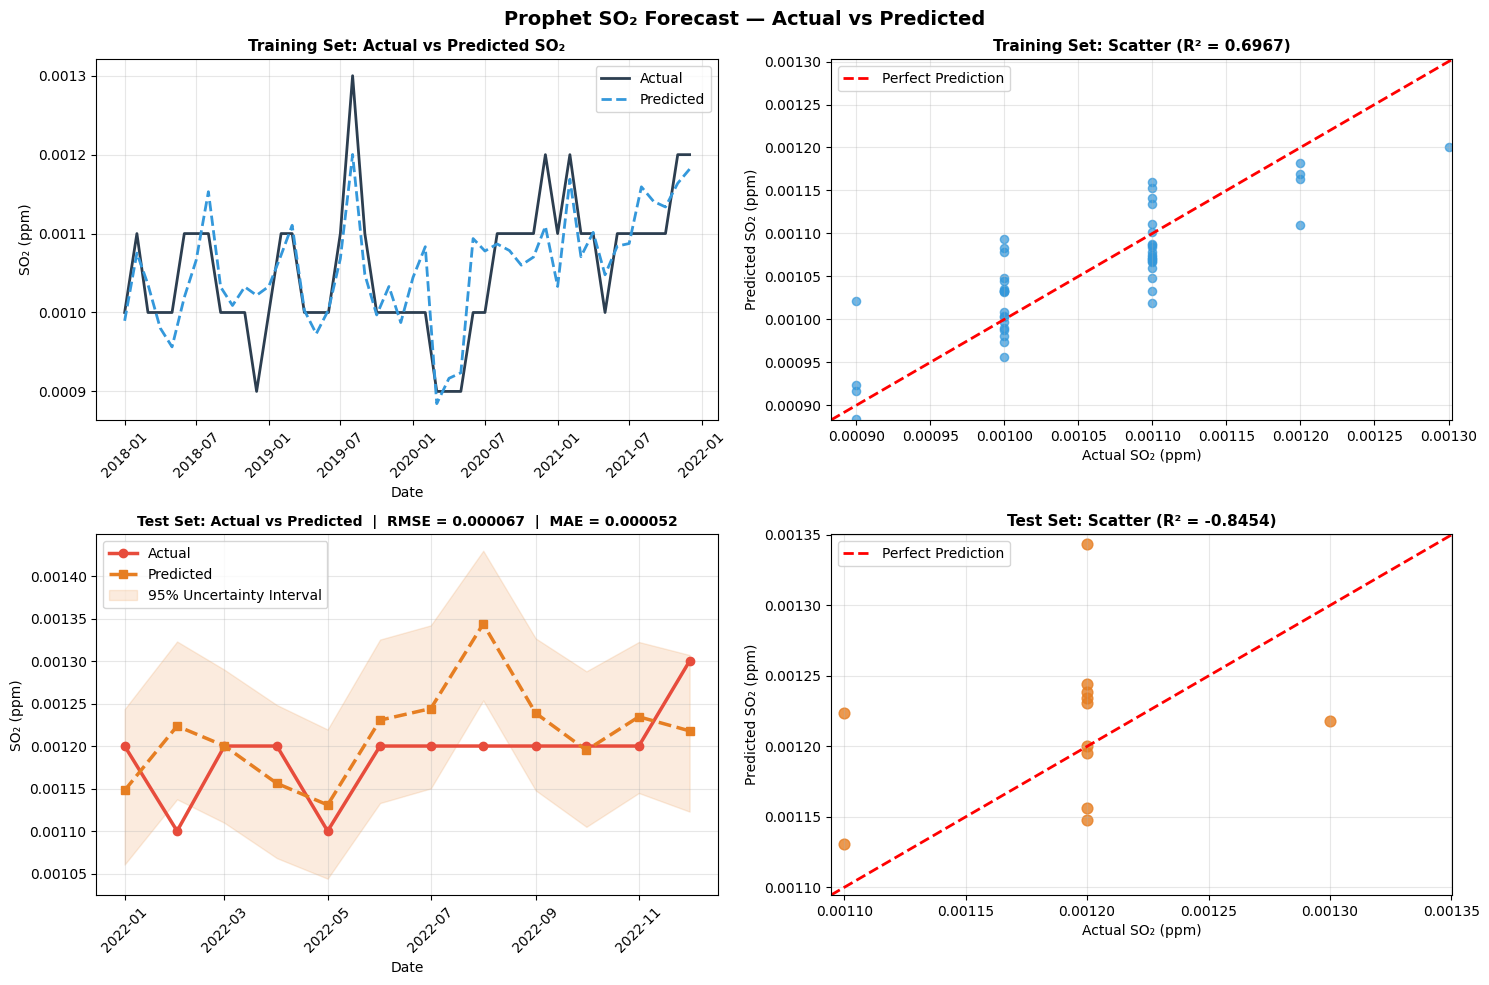

Saved: 02_actual_vs_predicted.png


In [11]:
train_dates = train_df['ds'].values
test_dates  = test_df['ds'].values

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Prophet SO₂ Forecast — Actual vs Predicted', fontsize=14, fontweight='bold')

# Training set — time series
axes[0, 0].plot(train_dates, y_actual_train, label='Actual',    lw=2,   color='#2c3e50')
axes[0, 0].plot(train_dates, y_pred_train,   label='Predicted', lw=2,   color='#3498db', ls='--')
axes[0, 0].set_title('Training Set: Actual vs Predicted SO₂', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Date'); axes[0, 0].set_ylabel('SO₂ (ppm)')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[0, 0].get_xticklabels(), rotation=45)

# Training set — scatter
axes[0, 1].scatter(y_actual_train, y_pred_train, alpha=0.7, s=35, color='#3498db')
lim = [min(y_actual_train.min(), y_pred_train.min())*0.998,
       max(y_actual_train.max(), y_pred_train.max())*1.002]
axes[0, 1].plot(lim, lim, 'r--', lw=2, label='Perfect Prediction')
axes[0, 1].set_title(f'Training Set: Scatter (R² = {train_r2:.4f})', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Actual SO₂ (ppm)'); axes[0, 1].set_ylabel('Predicted SO₂ (ppm)')
axes[0, 1].set_xlim(lim); axes[0, 1].set_ylim(lim)
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# Test set — time series with uncertainty interval
axes[1, 0].plot(test_dates, y_actual_test, label='Actual',    lw=2.5, color='#e74c3c', marker='o', ms=6)
axes[1, 0].plot(test_dates, y_pred_test,   label='Predicted', lw=2.5, color='#e67e22', ls='--', marker='s', ms=6)
axes[1, 0].fill_between(test_dates, y_lower_test, y_upper_test,
                          alpha=0.15, color='#e67e22', label='95% Uncertainty Interval')
axes[1, 0].set_title(
    f'Test Set: Actual vs Predicted  |  RMSE = {test_rmse:.6f}  |  MAE = {test_mae:.6f}',
    fontsize=10, fontweight='bold')
axes[1, 0].set_xlabel('Date'); axes[1, 0].set_ylabel('SO₂ (ppm)')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[1, 0].get_xticklabels(), rotation=45)

# Test set — scatter
axes[1, 1].scatter(y_actual_test, y_pred_test, alpha=0.8, s=60, color='#e67e22')
lim2 = [min(y_actual_test.min(), y_pred_test.min())*0.995,
        max(y_actual_test.max(), y_pred_test.max())*1.005]
axes[1, 1].plot(lim2, lim2, 'r--', lw=2, label='Perfect Prediction')
axes[1, 1].set_title(f'Test Set: Scatter (R² = {test_r2:.4f})', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Actual SO₂ (ppm)'); axes[1, 1].set_ylabel('Predicted SO₂ (ppm)')
axes[1, 1].set_xlim(lim2); axes[1, 1].set_ylim(lim2)
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_actual_vs_predicted.png')


## Section 11 — Residual Analysis

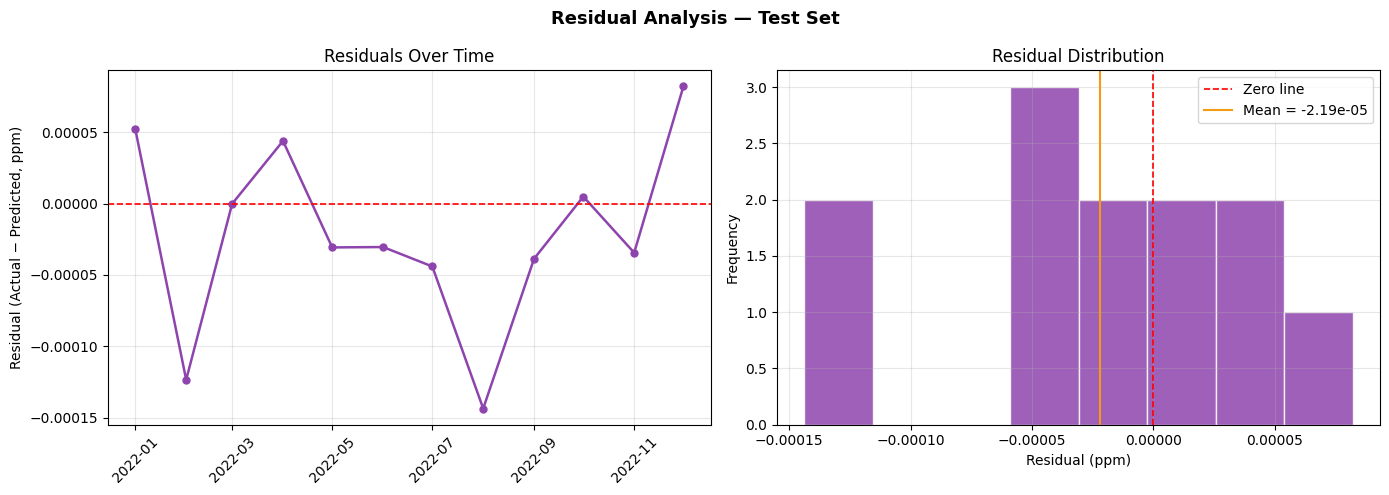

Saved: 03_residual_analysis.png
  Residual mean : -0.000022  (ideally close to 0)
  Residual std  : 0.000063


In [12]:
residuals = y_actual_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Residual Analysis — Test Set', fontsize=13, fontweight='bold')

axes[0].plot(test_dates, residuals, color='#8e44ad', lw=1.8, marker='o', ms=5)
axes[0].axhline(0, color='red', ls='--', lw=1.2)
axes[0].set_title('Residuals Over Time')
axes[0].set_ylabel('Residual (Actual − Predicted, ppm)')
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[0].get_xticklabels(), rotation=45)

axes[1].hist(residuals, bins=8, color='#8e44ad', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', ls='--', lw=1.2, label='Zero line')
axes[1].axvline(residuals.mean(), color='#f39c12', ls='-', lw=1.5,
                label=f'Mean = {residuals.mean():.2e}')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (ppm)'); axes[1].set_ylabel('Frequency')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_residual_analysis.png')
print(f'  Residual mean : {residuals.mean():.6f}  (ideally close to 0)')
print(f'  Residual std  : {residuals.std():.6f}')


## Section 12 — Prophet Component Decomposition

Prophet uniquely decomposes the forecast into interpretable components: trend,
yearly seasonality, and the contribution of each external regressor. This plot
directly shows how IPI growth and electricity each influence the SO₂ forecast —
providing evidence for or against the project hypothesis.


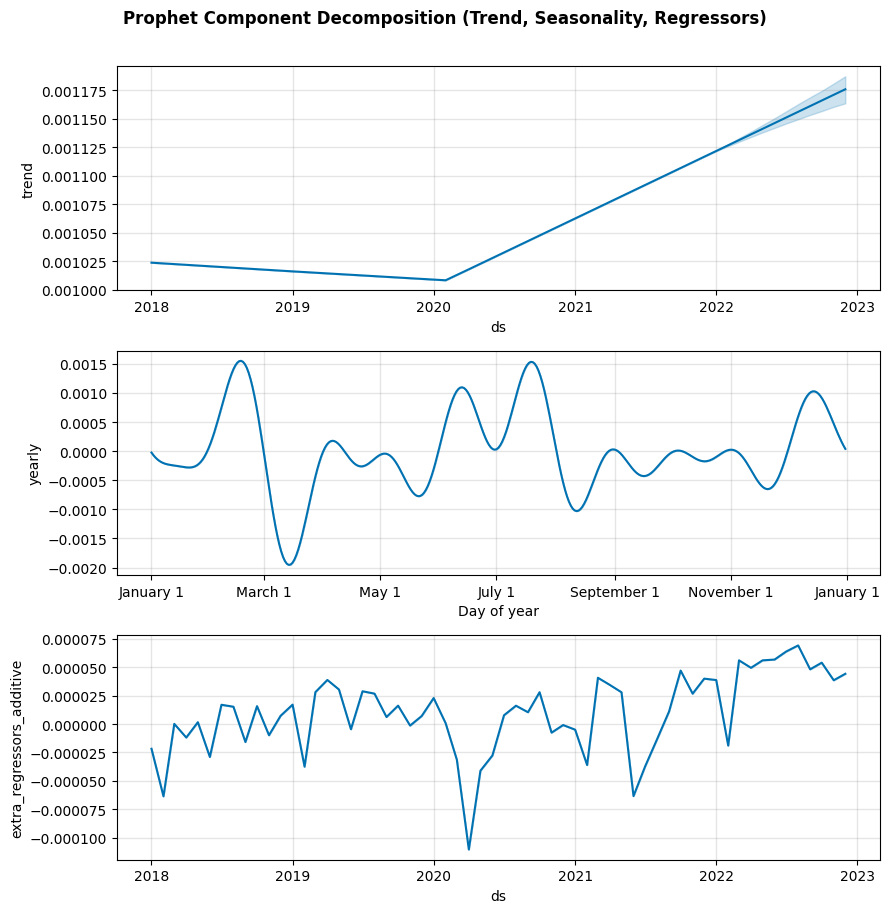

Saved: 04_prophet_components.png

Interpretation:
  trend       — long-run direction of SO₂ levels over 2018–2022
  yearly      — within-year seasonal pattern of SO₂
  ipi_growth  — marginal effect of IPI growth rate on SO₂
  elec_local  — marginal effect of local electricity consumption on SO₂


In [13]:
# Build full-period dataframe for component plotting
full_df = prophet_df.copy()
full_forecast = model.predict(full_df[['ds', 'ipi_growth', 'elec_local']])

fig = model.plot_components(full_forecast)
fig.suptitle('Prophet Component Decomposition (Trend, Seasonality, Regressors)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('04_prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04_prophet_components.png')
print()
print('Interpretation:')
print('  trend       — long-run direction of SO₂ levels over 2018–2022')
print('  yearly      — within-year seasonal pattern of SO₂')
print('  ipi_growth  — marginal effect of IPI growth rate on SO₂')
print('  elec_local  — marginal effect of local electricity consumption on SO₂')


## Section 13 — Full Forecast Plot with Uncertainty Interval

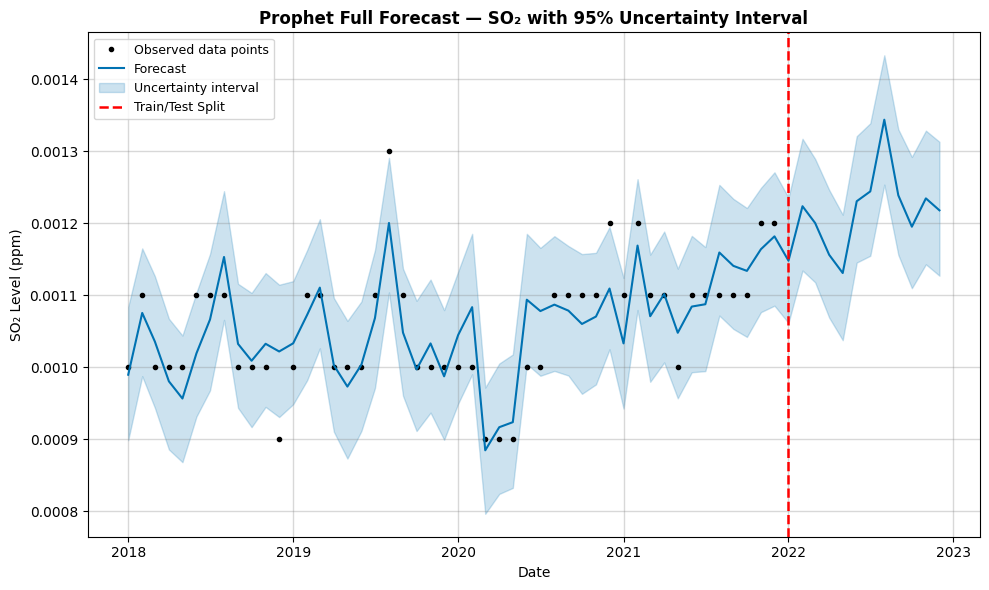

Saved: 05_prophet_full_forecast.png


In [14]:
fig = model.plot(full_forecast)
ax  = fig.gca()

split_date = test_df['ds'].iloc[0]
ax.axvline(x=split_date, color='red', ls='--', lw=1.8, label='Train/Test Split')
ax.legend(fontsize=9)
ax.set_title('Prophet Full Forecast — SO₂ with 95% Uncertainty Interval',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('SO₂ Level (ppm)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('05_prophet_full_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_prophet_full_forecast.png')


## Section 14 — Save Results Summary

In [15]:
summary = pd.DataFrame({
    'Model'      : ['Prophet'],
    'Train RMSE' : [round(train_rmse, 6)],
    'Test RMSE'  : [round(test_rmse,  6)],
    'Train MAE'  : [round(train_mae,  6)],
    'Test MAE'   : [round(test_mae,   6)],
    'Train R2'   : [round(train_r2,   4)],
    'Test R2'    : [round(test_r2,    4)],
    'Best Params': [str(best_params)]
})

summary.to_csv('prophet_results_summary.csv', index=False)
print('Saved: prophet_results_summary.csv')
print()
print(summary.drop(columns='Best Params').to_string(index=False))
print()
print('Best hyperparameters used:')
for k, v in best_params.items():
    print(f'  {k:<28} : {v}')


Saved: prophet_results_summary.csv

  Model  Train RMSE  Test RMSE  Train MAE  Test MAE  Train R2  Test R2
Prophet    0.000046   0.000067   0.000037  0.000052    0.6967  -0.8454

Best hyperparameters used:
  changepoint_prior_scale      : 0.1
  seasonality_prior_scale      : 1
  seasonality_mode             : additive
